<a href="https://colab.research.google.com/github/MoeTahech/real-fake-face-detection-thesis/blob/main/notebooks/02_finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 — Phase 2: Deeper Fine-Tuning
Unfreezes the last residual block (`layer4`) of ResNet18, instead of only the final
layer as in the baseline — lets the network adapt higher-level features specifically
to forgery artifacts.

Requires `01_baseline.ipynb` to have been run at least once (so `best_model.pth`
already exists in your Drive, for comparison at the end).

Runtime → Change runtime type → GPU, then run cells top to bottom.

### Step 1 — Confirm you have a GPU

In [ ]:
!nvidia-smi

Sun Jul 26 01:00:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Step 2 — Mount Google Drive

Connects your Drive so checkpoints can be saved/loaded from
`My Drive/thesis_checkpoints`, surviving across separate Colab sessions
and separate notebooks.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
CHECKPOINT_DIR = '/content/drive/MyDrive/thesis_checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print("Checkpoints will be saved to / loaded from:", CHECKPOINT_DIR)

Mounted at /content/drive
Checkpoints will be saved to / loaded from: /content/drive/MyDrive/thesis_checkpoints


### Step 3 — Kaggle API access

Upload your `kaggle.json` (from https://www.kaggle.com/settings/account →
Create New Token). Only needed once per Colab session.

In [ ]:
import os

KAGGLE_API_TOKEN = os.getenv("KGAT_305e81603250999b12324cc02e529f89")


### Step 4 — Download and link the primary dataset (140k Real and Fake Faces)

In [ ]:
!pip install -q kaggle

!kaggle datasets download -d xhlulu/140k-real-and-fake-faces
!unzip -q 140k-real-and-fake-faces.zip -d data_raw
!find data_raw -maxdepth 4 -type d

Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
100% 3.75G/3.75G [03:04<00:00, 21.9MB/s]

data_raw
data_raw/real_vs_fake
data_raw/real_vs_fake/real-vs-fake
data_raw/real_vs_fake/real-vs-fake/train
data_raw/real_vs_fake/real-vs-fake/train/real
data_raw/real_vs_fake/real-vs-fake/train/fake
data_raw/real_vs_fake/real-vs-fake/valid
data_raw/real_vs_fake/real-vs-fake/valid/real
data_raw/real_vs_fake/real-vs-fake/valid/fake
data_raw/real_vs_fake/real-vs-fake/test
data_raw/real_vs_fake/real-vs-fake/test/real
data_raw/real_vs_fake/real-vs-fake/test/fake


In [ ]:
import os

def find_split_root(root="data_raw"):
    for dirpath, dirnames, filenames in os.walk(root):
        if "train" in dirnames:
            train_path = os.path.join(dirpath, "train")
            if os.path.isdir(os.path.join(train_path, "real")) and os.path.isdir(os.path.join(train_path, "fake")):
                return dirpath
    return None

base = find_split_root("data_raw")
base_abs = os.path.abspath(base)
print("Found dataset root:", base_abs)

os.makedirs("data", exist_ok=True)
val_name = "valid" if os.path.isdir(os.path.join(base, "valid")) else "val"

!ln -sfn "{base_abs}/train" data/train
!ln -sfn "{base_abs}/{val_name}" data/val

print("train/real:", len(os.listdir("data/train/real")))
print("train/fake:", len(os.listdir("data/train/fake")))
print("val/real:", len(os.listdir("data/val/real")))
print("val/fake:", len(os.listdir("data/val/fake")))

Found dataset root: /content/data_raw/real_vs_fake/real-vs-fake
train/real: 50000
train/fake: 50000
val/real: 10000
val/fake: 10000


### Step 5 (optional but recommended) — Small subset for a fast sanity check

Run a quick training pass on a small sample before committing to the full run.

In [ ]:
import os, random, shutil

def make_subset(src_split, dst_split, n_per_class):
    for cls in ["real", "fake"]:
        src_dir = f"data/{src_split}/{cls}"
        dst_dir = f"data_small/{dst_split}/{cls}"
        os.makedirs(dst_dir, exist_ok=True)
        files = os.listdir(src_dir)
        random.shuffle(files)
        for f in files[:n_per_class]:
            shutil.copy(os.path.join(src_dir, f), os.path.join(dst_dir, f))

make_subset("train", "train", 1000)
make_subset("val", "val", 250)
print("Small subset ready in ./data_small")

Small subset ready in ./data_small


### Step 6 — Write the deeper fine-tuning training script

In [ ]:
%%writefile train_finetune.py
"""
Deeper fine-tuning: unfreeze the last residual block (layer4) of ResNet18,
not just the final classification layer.

Usage:
    python train_finetune.py --data_dir ./data --epochs 5 --batch_size 64 --lr 1e-4 --checkpoint_dir .
"""
import argparse
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from tqdm import tqdm


def get_dataloaders(data_dir, batch_size, img_size=224):
    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    train_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        normalize,
    ])
    val_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        normalize,
    ])
    train_set = datasets.ImageFolder(f"{data_dir}/train", transform=train_transform)
    val_set = datasets.ImageFolder(f"{data_dir}/val", transform=val_transform)
    print("Class mapping:", train_set.class_to_idx)
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2)
    return train_loader, val_loader, train_set.class_to_idx


def build_model():
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    for param in model.layer4.parameters():
        param.requires_grad = True
    model.fc = nn.Linear(model.fc.in_features, 2)
    return model


def run_epoch(model, loader, criterion, optimizer, device, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for images, labels in tqdm(loader, desc="train" if train else "val"):
            images, labels = images.to(device), labels.to(device)
            if train:
                optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--data_dir", type=str, default="./data")
    parser.add_argument("--epochs", type=int, default=5)
    parser.add_argument("--batch_size", type=int, default=64)
    parser.add_argument("--lr", type=float, default=1e-4)
    parser.add_argument("--checkpoint_dir", type=str, default=".")
    args = parser.parse_args()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    train_loader, val_loader, class_to_idx = get_dataloaders(args.data_dir, args.batch_size)
    model = build_model().to(device)
    criterion = nn.CrossEntropyLoss()

    trainable_params = [p for p in model.parameters() if p.requires_grad]
    n_trainable = sum(p.numel() for p in trainable_params)
    n_total = sum(p.numel() for p in model.parameters())
    print(f"Trainable parameters: {n_trainable:,} / {n_total:,}")

    optimizer = torch.optim.Adam(trainable_params, lr=args.lr)

    os.makedirs(args.checkpoint_dir, exist_ok=True)
    save_path = os.path.join(args.checkpoint_dir, "best_model_finetuned.pth")

    best_val_acc = 0.0
    for epoch in range(args.epochs):
        print(f"\nEpoch {epoch + 1}/{args.epochs}")
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, device, train=True)
        val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer, device, train=False)
        print(f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({"model_state": model.state_dict(), "class_to_idx": class_to_idx}, save_path)
            print(f"Saved new best model to {save_path} (val_acc={val_acc:.4f})")

    print(f"\nDone. Best validation accuracy: {best_val_acc:.4f}")
    print(f"Final checkpoint is at: {save_path}")


if __name__ == "__main__":
    main()


Writing train_finetune.py


### Step 7 — Train (small subset sanity check, then full run)

Lower learning rate (`1e-4` vs `1e-3` in the baseline) since more parameters are
now training — protects the pretrained `layer4` weights from being destroyed by
too large an update early on.

In [ ]:
!python train_finetune.py --data_dir ./data_small --epochs 3 --batch_size 32 --lr 1e-4 --checkpoint_dir "{CHECKPOINT_DIR}"

Using device: cuda
Class mapping: {'fake': 0, 'real': 1}
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100% 44.7M/44.7M [00:00<00:00, 175MB/s]
Trainable parameters: 8,394,754 / 11,177,538

Epoch 1/3
train: 100% 63/63 [00:09<00:00,  6.87it/s]
val: 100% 16/16 [00:01<00:00, 10.60it/s]
train_loss=0.5276 train_acc=0.7350 val_loss=0.4223 val_acc=0.8080
Saved new best model to /content/drive/MyDrive/thesis_checkpoints/best_model_finetuned.pth (val_acc=0.8080)

Epoch 2/3
train: 100% 63/63 [00:05<00:00, 11.05it/s]
val: 100% 16/16 [00:01<00:00,  9.87it/s]
train_loss=0.2100 train_acc=0.9280 val_loss=0.2857 val_acc=0.8740
Saved new best model to /content/drive/MyDrive/thesis_checkpoints/best_model_finetuned.pth (val_acc=0.8740)

Epoch 3/3
train: 100% 63/63 [00:07<00:00,  8.51it/s]
val: 100% 16/16 [00:01<00:00, 10.71it/s]
train_loss=0.1048 train_acc=0.9650 val_loss=0.2856 val_acc=0.8800
Saved new best model to /c

In [ ]:
!python train_finetune.py --data_dir ./data --epochs 5 --batch_size 64 --lr 1e-4 --checkpoint_dir "{CHECKPOINT_DIR}"

Using device: cuda
Class mapping: {'fake': 0, 'real': 1}
Trainable parameters: 8,394,754 / 11,177,538

Epoch 1/5
train: 100% 1563/1563 [05:54<00:00,  4.41it/s]
val: 100% 313/313 [01:04<00:00,  4.82it/s]
train_loss=0.1461 train_acc=0.9407 val_loss=0.0685 val_acc=0.9738
Saved new best model to /content/drive/MyDrive/thesis_checkpoints/best_model_finetuned.pth (val_acc=0.9738)

Epoch 2/5
train: 100% 1563/1563 [05:38<00:00,  4.61it/s]
val: 100% 313/313 [01:04<00:00,  4.82it/s]
train_loss=0.0525 train_acc=0.9799 val_loss=0.0600 val_acc=0.9768
Saved new best model to /content/drive/MyDrive/thesis_checkpoints/best_model_finetuned.pth (val_acc=0.9768)

Epoch 3/5
train: 100% 1563/1563 [05:14<00:00,  4.96it/s]
val: 100% 313/313 [01:05<00:00,  4.77it/s]
train_loss=0.0331 train_acc=0.9881 val_loss=0.0508 val_acc=0.9810
Saved new best model to /content/drive/MyDrive/thesis_checkpoints/best_model_finetuned.pth (val_acc=0.9810)

Epoch 4/5
train: 100% 1563/1563 [05:19<00:00,  4.90it/s]
val: 100% 313/3

### Step 8 — Evaluate on the full test set, compare against Baseline #1

In [ ]:
import torch, torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
test_transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(), normalize])

test_dir = "data_raw/real_vs_fake/real-vs-fake/test"
test_set = datasets.ImageFolder(test_dir, transform=test_transform)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False, num_workers=2)
print("Class mapping:", test_set.class_to_idx)

checkpoint = torch.load(f"{CHECKPOINT_DIR}/best_model_finetuned.pth", map_location=device)
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 2)
model.load_state_dict(checkpoint["model_state"])
model.to(device).eval()

all_labels, all_probs, all_preds = [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        logits = model(images)
        probs = torch.softmax(logits, dim=1)[:, 1]
        preds = logits.argmax(dim=1)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)
print(f"Fine-tuned Test Accuracy: {acc:.4f}")
print(f"Fine-tuned Test AUC: {auc:.4f}")
print("\nConfusion matrix:\n", confusion_matrix(all_labels, all_preds))
print("\n", classification_report(all_labels, all_preds, target_names=list(test_set.class_to_idx.keys())))

print("\n--- Compare against Baseline #1 ---")
print("Baseline #1 (frozen backbone):   Accuracy=0.8077  AUC=0.8883")
print(f"Phase 2 (fine-tuned layer4):      Accuracy={acc:.4f}  AUC={auc:.4f}")

Class mapping: {'fake': 0, 'real': 1}
Fine-tuned Test Accuracy: 0.9881
Fine-tuned Test AUC: 0.9993

Confusion matrix:
 [[9909   91]
 [ 146 9854]]

               precision    recall  f1-score   support

        fake       0.99      0.99      0.99     10000
        real       0.99      0.99      0.99     10000

    accuracy                           0.99     20000
   macro avg       0.99      0.99      0.99     20000
weighted avg       0.99      0.99      0.99     20000


--- Compare against Baseline #1 ---
Baseline #1 (frozen backbone):   Accuracy=0.8077  AUC=0.8883
Phase 2 (fine-tuned layer4):      Accuracy=0.9881  AUC=0.9993


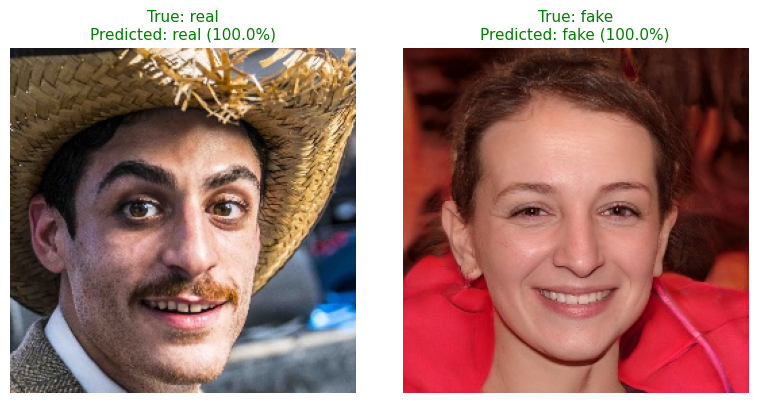

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import torch, torch.nn as nn, torch.nn.functional as F
from torchvision import transforms, models
import os, random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the fine-tuned model
checkpoint = torch.load(f"{CHECKPOINT_DIR}/best_model_finetuned.pth", map_location=device)
class_to_idx = checkpoint["class_to_idx"]
idx_to_class = {v: k for k, v in class_to_idx.items()}

model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 2)
model.load_state_dict(checkpoint["model_state"])
model.to(device).eval()

normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(), normalize])

def predict(image_path):
    image = Image.open(image_path).convert("RGB")
    tensor = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = F.softmax(model(tensor), dim=1)[0]
    pred_idx = probs.argmax().item()
    return image, idx_to_class[pred_idx], probs[pred_idx].item() * 100

# Pick one random real and one random fake image from the test set
test_root = "data_raw/real_vs_fake/real-vs-fake/test"
real_dir = os.path.join(test_root, "real")
fake_dir = os.path.join(test_root, "fake")

real_img_path = os.path.join(real_dir, random.choice(os.listdir(real_dir)))
fake_img_path = os.path.join(fake_dir, random.choice(os.listdir(fake_dir)))

samples = [("real", real_img_path), ("fake", fake_img_path)]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, (true_label, path) in zip(axes, samples):
    image, pred_label, confidence = predict(path)
    correct = (pred_label == true_label)
    color = "green" if correct else "red"
    ax.imshow(image)
    ax.axis("off")
    ax.set_title(f"True: {true_label}\nPredicted: {pred_label} ({confidence:.1f}%)",
                 color=color, fontsize=11)

plt.tight_layout()
plt.show()

---
### Save for your report
Trainable parameter count, per-epoch metrics, fine-tuned test accuracy/AUC/confusion
matrix, and the comparison vs. Baseline #1. Saved as `best_model_finetuned.pth` in Drive
(separate from `best_model.pth`, so Baseline #1 stays intact).

**Next notebook: `03_cross_dataset_eval.ipynb`** — no retraining needed, just loads
both checkpoints from Drive.